In [86]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
from scipy.optimize import curve_fit
import matplotlib.colors as mcolors

_dpi = 100


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

#(10,10), size = 25

rc('text', usetex=False)
rc('font', family='serif', size = 15)

[0.00000000e+00 4.00533333e-06 1.60426667e-05 ... 9.28541329e+00
 9.30935333e+00 9.33333333e+00]
[ 0.00000000e+00  3.99466667e-06  1.59573333e-05 ... -1.31738129e+00
 -1.32534533e+00 -1.33333333e+00]


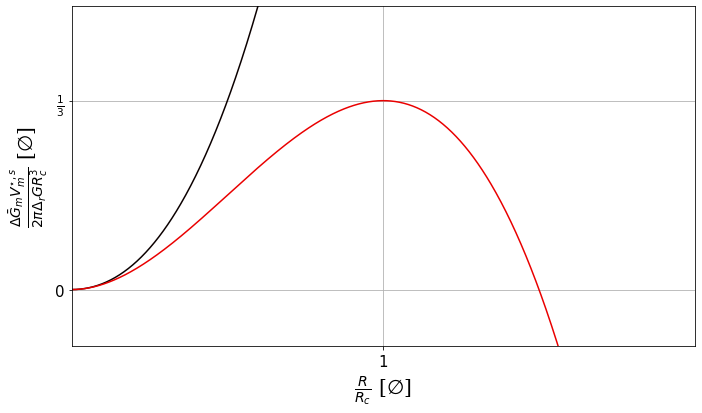

In [126]:
def get_G(R, Rc) : 
    return - (R/Rc)**2 * (2/3 * (R/Rc) - 1)
    #else : 
    #    return - (R/Rc)**2 * (2/3 * (R/Rc) - 1)

Vm = 19.78 #cm3/mol

ylim = (-0.1, 0.5)
xlim = (0,1)

R = np.linspace(0, 1, num = 1001)

Rc = np.array([-0.5, 0.5])
Rc_labels = np.array(["$0$", "$1$"])
colors = colormap(len(Rc)+2, name = 'hot')


fig = plt.figure(figsize=(10,6))
ax = fig.subplots()
for n in range(len(Rc)) : 
    print(get_G(R, Rc[n]))
    ax.plot(R, get_G(R, Rc[n]), color = colors[n])
    
ax.set_ylim(*ylim)
ax.set_xlim(*xlim)

mask = Rc > 0
ax.set_xticks(Rc[mask])
ax.set_xticklabels(Rc_labels[mask])

ax.set_yticks([0, 1/3])
ax.set_yticklabels(["$0$", "$\\frac{1}{3}$"])

ax.set_xlabel("$\\frac{R}{R_c}$ [$\emptyset$]", size = 20)
ax.set_ylabel("$\\frac{\Delta \\bar{G}_m V^{\star, s}_m}{2 \pi \Delta_r G R_c^3}$ [$\emptyset$]", size = 20)

ax.grid()

# Create a colorbar with discrete color labels
#bounds = np.arange(len(Rc)+1) - 0.5
#cmap= mcolors.ListedColormap(colors)
#sm = plt.cm.ScalarMappable(cmap=cmap)
#sm.set_array([])  # This step is necessary to create a mappable
#cbar = plt.colorbar(sm, ticks=np.arange(len(Rc)), boundaries = bounds)
#cbar.set_ticklabels(["$R_0 < 0$", "$R_1 > 0 > R_0$", "$R_2 > R_1$", "$R_3 > R_2$"])
#cbar.set_label("Influence de la taille du rayon critique sur l'enthalpie libre")

fig.tight_layout()

fig.savefig("Fig24.pdf", dpi = _dpi)

